# Embedding Analysis: Tiago's Teleport Session Data

Evaluating embedding strategies for security session search.

**Questions:**
1. Which document chunks (DOC 0-11) are most useful?
2. Can we reduce dimensions (3072 → 1024) without losing quality?
3. Which embedding model gives best results for the cost?

In [ ]:
# Install dependencies
%pip install openai numpy pandas matplotlib scikit-learn
%env OPENAI_API_KEY=meow

Note: you may need to restart the kernel to use updated packages.
env: OPENAI_API_KEY=sk-proj-..


In [2]:
import os
import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

client = OpenAI()  # Uses OPENAI_API_KEY env var

## Tiago's Original Session Data

The raw JSON from Teleport session recording summarization.

In [3]:
# Tiago's original session summary JSON from Teleport
session_data = {
    "session_id": "8d73c824-dfbe-44d5-b6a6-0f1a95f2902f",
    "state": "SUMMARY_STATE_SUCCESS",
    "inference_started_at": "2025-12-17T14:28:01.748727738Z",
    "inference_finished_at": "2025-12-17T14:28:42.535795117Z",
    "model_name": "openai-chat-gpt",
    "enhanced_summary": {
        "short_description": "Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.",
        "detailed_description": """## Session Overview

This session contained a mix of routine system activities and one notable security-relevant modification.

### Activities Performed

1. **Network Connectivity Testing** - Verified internet connectivity by pinging google.com

2. **System Directory Exploration** - Listed contents of /etc directory with detailed attributes

3. **Hosts File Modification** - Edited /etc/hosts to add an entry referencing a 'reverseshell' domain, redirecting it to 0.0.0.0 (sinkholing)

4. **Miscellaneous** - Ran the nyancat animation program and viewed system processes with top

### Key Finding

The /etc/hosts modification is the most significant activity in this session. The entry appears to be DNS sinkholing for a domain containing 'reverseshell' in the name. This action could represent:
- **Defensive measure**: Blocking a known malicious domain to prevent outbound C2 communication
- **Cover-up activity**: Attempting to hide evidence of prior malicious activity by preventing DNS resolution

The context is ambiguous - this could be legitimate security hardening or an attempt to conceal tracks after compromise.""",
        "risk_level": "RISK_LEVEL_HIGH",
        "suspicious_activities": [
            "Modified /etc/hosts to add entry sinkholing a domain containing 'reverseshell' keyword to 0.0.0.0",
            "DNS sinkholing pattern that could indicate blocking C2 communications or concealing prior malicious activity"
        ],
        "notable_command_indexes": [2],
        "commands": [
            {
                "command": "ping google.com",
                "category": "COMMAND_CATEGORY_NETWORK",
                "success": True,
                "threat_category": "THREAT_CATEGORY_NONE",
                "timeline_title": "Tested network connectivity to google.com",
                "short_description": "Tested network connectivity to google.com using ICMP ping",
                "detailed_description": "Executed ping command to google.com, successfully sending 3 ICMP packets with 0% packet loss. Command was terminated normally by user after verifying connectivity.",
                "start_offset": "0s",
                "end_offset": "5.023s"
            },
            {
                "command": "ls -al /etc",
                "category": "COMMAND_CATEGORY_FILE_OPERATION",
                "success": True,
                "risk_score": 5,
                "threat_category": "THREAT_CATEGORY_DISCOVERY",
                "timeline_title": "Listed /etc directory contents",
                "short_description": "Listed all files and directories in /etc with detailed attributes.",
                "detailed_description": "Executed ls -al to display all files in /etc including hidden files, permissions, ownership, and timestamps. This is a standard reconnaissance command to view system configuration files.",
                "mitre_attack_ids": ["T1083"],
                "start_offset": "5.023s",
                "end_offset": "7.510s"
            },
            {
                "command": "vim /etc/hosts",
                "category": "COMMAND_CATEGORY_SYSTEM_CONFIG",
                "success": True,
                "risk_level": "RISK_LEVEL_HIGH",
                "risk_score": 70,
                "threat_category": "THREAT_CATEGORY_DEFENSE_EVASION",
                "timeline_title": "Modified /etc/hosts with suspicious entry",
                "short_description": "Modified /etc/hosts file adding entry to block 'reverseshell' domain.",
                "detailed_description": "Edited /etc/hosts and saved changes including an entry mapping 0.0.0.0 to 'reverseshell'. This entry name suggests either blocking outbound connections to a reverse shell server or evidence of malware-related DNS manipulation.",
                "suspicious_flags": [
                    "Added entry referencing 'reverseshell' to /etc/hosts",
                    "DNS redirection to 0.0.0.0 for suspicious domain"
                ],
                "sensitive_items": ["/etc/hosts"],
                "suspicious_patterns": [
                    "Host entry containing 'reverseshell' keyword indicating potential malware activity or cover-up",
                    "DNS sinkholing pattern that could indicate blocking C2 or hiding tracks"
                ],
                "iocs": ["reverseshell"],
                "mitre_attack_ids": ["T1565.001", "T1562.001"],
                "has_sensitive_data": True,
                "start_offset": "7.510s",
                "end_offset": "15.315s"
            },
            {
                "command": "nyancat",
                "category": "COMMAND_CATEGORY_OTHER",
                "success": True,
                "threat_category": "THREAT_CATEGORY_NONE",
                "timeline_title": "Ran nyancat animation",
                "short_description": "Executed nyancat animation program",
                "detailed_description": "Ran the nyancat terminal animation program which displayed for approximately 4 seconds before being terminated with Ctrl+C.",
                "start_offset": "15.315s",
                "end_offset": "21.295s"
            },
            {
                "command": "top",
                "category": "COMMAND_CATEGORY_PROCESS",
                "success": True,
                "threat_category": "THREAT_CATEGORY_NONE",
                "timeline_title": "Viewed running processes with top",
                "short_description": "Displayed real-time system process information",
                "detailed_description": "Executed top to view real-time system statistics including CPU, memory usage, and running processes. Shows 5 tasks total with teleport and bash among the processes.",
                "start_offset": "21.295s",
                "end_offset": "27.611s"
            },
            {
                "command": "exit",
                "category": "COMMAND_CATEGORY_OTHER",
                "success": True,
                "threat_category": "THREAT_CATEGORY_NONE",
                "timeline_title": "Exited shell session",
                "short_description": "Terminated the current shell session",
                "detailed_description": "Executed exit command to logout from the root shell session. This is a normal session termination action.",
                "start_offset": "27.611s",
                "end_offset": "29.109s"
            }
        ]
    }
}

print(f"Session ID: {session_data['session_id']}")
print(f"Risk Level: {session_data['enhanced_summary']['risk_level']}")
print(f"Commands: {len(session_data['enhanced_summary']['commands'])}")

Session ID: 8d73c824-dfbe-44d5-b6a6-0f1a95f2902f
Risk Level: RISK_LEVEL_HIGH
Commands: 6


## Tiago's Embedding Documents (DOC 0-11)

These are the actual text chunks generated from the session data for vector embedding.

In [4]:
# Tiago's actual embedding documents (DOC 0-11)

docs = {
    "DOC_0_session_overview": """Risk Level: RISK_LEVEL_HIGH. Description: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Detailed Analysis: ## Session Overview

This session contained a mix of routine system activities and one notable security-relevant modification.

### Activities Performed

1. **Network Connectivity Testing** - Verified internet connectivity by pinging google.com

2. **System Directory Exploration** - Listed contents of /etc directory with detailed attributes

3. **Hosts File Modification** - Edited /etc/hosts to add an entry referencing a 'reverseshell' domain, redirecting it to 0.0.0.0 (sinkholing)

4. **Miscellaneous** - Ran the nyancat animation program and viewed system processes with top

### Key Finding

The /etc/hosts modification is the most significant activity in this session. The entry appears to be DNS sinkholing for a domain containing 'reverseshell' in the name. This action could represent:
- **Defensive measure**: Blocking a known malicious domain to prevent outbound C2 communication
- **Cover-up activity**: Attempting to hide evidence of prior malicious activity by preventing DNS resolution

The context is ambiguous - this could be legitimate security hardening or an attempt to conceal tracks after compromise.

Suspicious Activities: Modified /etc/hosts to add entry sinkholing a domain containing 'reverseshell' keyword to 0.0.0.0; DNS sinkholing pattern that could indicate blocking C2 communications or concealing prior malicious activity""",

    "DOC_1_high_risk_command": """Command: vim /etc/hosts. Category: COMMAND_CATEGORY_SYSTEM_CONFIG. Threat: THREAT_CATEGORY_DEFENSE_EVASION. Risk Score: 70. Modified /etc/hosts file adding entry to block 'reverseshell' domain.. Edited /etc/hosts and saved changes including an entry mapping 0.0.0.0 to 'reverseshell'. This entry name suggests either blocking outbound connections to a reverse shell server or evidence of malware-related DNS manipulation.. Suspicious: Added entry referencing 'reverseshell' to /etc/hosts; DNS redirection to 0.0.0.0 for suspicious domain. Patterns: Host entry containing 'reverseshell' keyword indicating potential malware activity or cover-up; DNS sinkholing pattern that could indicate blocking C2 or hiding tracks. MITRE ATT&CK: T1565.001, T1562.001. Session Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.""",

    "DOC_2_network_commands": """Command group (1 commands). Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Categories: COMMAND_CATEGORY_NETWORK (1), 

Commands:
- ping google.com: Tested network connectivity to google.com using ICMP ping""",

    "DOC_3_file_operation": """Command group (1 commands). Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Categories: COMMAND_CATEGORY_FILE_OPERATION (1), 
Threat Categories: THREAT_CATEGORY_DISCOVERY (1), 

Commands:
- ls -al /etc: Listed all files and directories in /etc with detailed attributes. (Risk: 5)""",

    "DOC_4_process_commands": """Command group (1 commands). Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Categories: COMMAND_CATEGORY_PROCESS (1), 

Commands:
- top: Displayed real-time system process information""",

    "DOC_5_benign_commands": """Benign session activity (2 commands). Categories: COMMAND_CATEGORY_OTHER (2), 
Commands executed: nyancat, exit,""",

    "DOC_6_activity_network": """Network Connectivity Testing: Verified internet connectivity by pinging google.com""",

    "DOC_7_activity_discovery": """System Directory Exploration: Listed contents of /etc directory with detailed attributes""",

    "DOC_8_activity_hosts": """Hosts File Modification: Edited /etc/hosts to add an entry referencing a 'reverseshell' domain, redirecting it to 0.0.0.0 (sinkholing)""",

    "DOC_9_activity_misc": """Miscellaneous: Ran the nyancat animation program and viewed system processes with top""",

    "DOC_10_suspicious_1": """Suspicious Activity: Modified /etc/hosts to add entry sinkholing a domain containing 'reverseshell' keyword to 0.0.0.0""",

    "DOC_11_suspicious_2": """Suspicious Activity: DNS sinkholing pattern that could indicate blocking C2 communications or concealing prior malicious activity"""
}

# Display all docs with their lengths
for name, text in docs.items():
    print(f"\n{'='*60}")
    print(f"{name} ({len(text)} chars)")
    print('='*60)
    print(text[:200] + "..." if len(text) > 200 else text)


DOC_0_session_overview (1529 chars)
Risk Level: RISK_LEVEL_HIGH. Description: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Detailed Analysis: ## Session Overview

This se...

DOC_1_high_risk_command (880 chars)
Command: vim /etc/hosts. Category: COMMAND_CATEGORY_SYSTEM_CONFIG. Threat: THREAT_CATEGORY_DEFENSE_EVASION. Risk Score: 70. Modified /etc/hosts file adding entry to block 'reverseshell' domain.. Edite...

DOC_2_network_commands (278 chars)
Command group (1 commands). Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Categories: COMMAND_CATEGORY_NETWORK (1), 

Commands...

DOC_3_file_operation (351 chars)
Command group (1 commands). Context: Mixed session with network testing and suspicious /etc/hosts modification adding 'reverseshell' domain entry.

Categories: COMMAND_CATEGORY_FILE_OPERATION (1), 
Th...

DOC_4_process_commands (255 chars)
Comm

## Test Queries with Ground Truth

Each query has expected matching documents. This lets us measure retrieval accuracy, not just raw similarity scores.

In [5]:
# Test queries with expected matching documents (ground truth)
test_queries_with_expected = [
    # (query, expected best docs)
    ("reverse shell activity", ["DOC_1_high_risk_command", "DOC_8_activity_hosts", "DOC_10_suspicious_1"]),
    ("hosts file modification", ["DOC_1_high_risk_command", "DOC_8_activity_hosts"]),
    ("high risk sessions", ["DOC_0_session_overview", "DOC_1_high_risk_command"]),
    ("reconnaissance before configuration change", ["DOC_0_session_overview"]),
    ("network testing followed by system modification", ["DOC_0_session_overview", "DOC_2_network_commands"]),
    ("discovery then defense evasion", ["DOC_0_session_overview", "DOC_3_file_operation"]),
    ("suspicious DNS manipulation", ["DOC_1_high_risk_command", "DOC_10_suspicious_1", "DOC_11_suspicious_2"]),
    ("potential C2 blocking", ["DOC_0_session_overview", "DOC_11_suspicious_2"]),
    ("attacker covering tracks", ["DOC_0_session_overview", "DOC_11_suspicious_2"]),
    ("T1565 data manipulation", ["DOC_1_high_risk_command"]),
    ("MITRE defense evasion techniques", ["DOC_1_high_risk_command"]),
    ("/etc/hosts sinkhole", ["DOC_1_high_risk_command", "DOC_8_activity_hosts"]),
    ("ping google.com", ["DOC_2_network_commands", "DOC_6_activity_network"]),
    ("ls -al /etc", ["DOC_3_file_operation", "DOC_7_activity_discovery"]),
    ("nyancat", ["DOC_5_benign_commands", "DOC_9_activity_misc"]),
]

test_queries = [q[0] for q in test_queries_with_expected]
expected_docs = {q[0]: q[1] for q in test_queries_with_expected}

print(f"Testing {len(test_queries)} queries with ground truth expectations")

Testing 15 queries with ground truth expectations


## Embedding Functions

Using OpenAI's embedding API. Cosine similarity measures how "close" two vectors are (1.0 = identical, 0.0 = unrelated).

In [6]:
def get_embedding(text: str, model: str = "text-embedding-3-small", dimensions: int = None) -> np.ndarray:
    """Get embedding for text using specified model and dimensions."""
    kwargs = {"model": model, "input": text}
    if dimensions:
        kwargs["dimensions"] = dimensions
    
    response = client.embeddings.create(**kwargs)
    return np.array(response.data[0].embedding)


def get_embeddings_batch(texts: list, model: str = "text-embedding-3-small", dimensions: int = None) -> np.ndarray:
    """Get embeddings for multiple texts in a single API call."""
    kwargs = {"model": model, "input": texts}
    if dimensions:
        kwargs["dimensions"] = dimensions
    
    response = client.embeddings.create(**kwargs)
    return np.array([item.embedding for item in response.data])


def similarity_score(embedding1: np.ndarray, embedding2: np.ndarray) -> float:
    """Calculate cosine similarity between two embeddings."""
    return cosine_similarity([embedding1], [embedding2])[0][0]

## Experiment 1: Retrieval Accuracy

**Goal:** Does the highest-scoring doc match our expectations?

**Metrics:**
- **Hit@1**: Is the top result one of the expected docs?
- **Hit@3**: Is any expected doc in top 3 results?
- **Short doc wins**: Do DOC 6-11 ever rank higher than DOC 0-1 for their specific queries?

In [7]:
# Embed all of Tiago's documents
model = "text-embedding-3-small"

print(f"Embedding {len(docs)} documents with {model}...")

doc_embeddings = {}
for name, text in docs.items():
    doc_embeddings[name] = get_embedding(text, model=model)
    print(f"  {name}: {len(doc_embeddings[name])} dims, {len(text)} chars")

# Embed all queries
print(f"\nEmbedding {len(test_queries)} queries...")
query_embeddings = get_embeddings_batch(test_queries, model=model)

Embedding 12 documents with text-embedding-3-small...
  DOC_0_session_overview: 1536 dims, 1529 chars
  DOC_1_high_risk_command: 1536 dims, 880 chars
  DOC_2_network_commands: 1536 dims, 278 chars
  DOC_3_file_operation: 1536 dims, 351 chars
  DOC_4_process_commands: 1536 dims, 255 chars
  DOC_5_benign_commands: 1536 dims, 112 chars
  DOC_6_activity_network: 1536 dims, 82 chars
  DOC_7_activity_discovery: 1536 dims, 88 chars
  DOC_8_activity_hosts: 1536 dims, 134 chars
  DOC_9_activity_misc: 1536 dims, 85 chars
  DOC_10_suspicious_1: 1536 dims, 118 chars
  DOC_11_suspicious_2: 1536 dims, 129 chars

Embedding 15 queries...


In [8]:
# Calculate similarity scores for each query against each document
results = []

for q_idx, query in enumerate(test_queries):
    q_emb = query_embeddings[q_idx]
    row = {"query": query}
    
    for doc_name, d_emb in doc_embeddings.items():
        row[doc_name] = similarity_score(q_emb, d_emb)
    
    results.append(row)

df_docs = pd.DataFrame(results)
df_docs = df_docs.set_index("query")

# Show top 3 docs for each query (more useful than full matrix)
print("TOP 3 MATCHING DOCS PER QUERY:\n Y means it was expected \n")
for query in df_docs.index:
    scores = df_docs.loc[query].sort_values(ascending=False)
    expected = expected_docs.get(query, [])
    print(f"Query: \"{query}\"")
    for i, (doc, score) in enumerate(scores.head(3).items()):
        marker = "Y" if doc in expected else " "
        print(f"  {marker} {i+1}. {doc}: {score:.3f}")
    print()

TOP 3 MATCHING DOCS PER QUERY:
 Y means it was expected 

Query: "reverse shell activity"
  Y 1. DOC_10_suspicious_1: 0.539
    2. DOC_0_session_overview: 0.523
  Y 3. DOC_1_high_risk_command: 0.511

Query: "hosts file modification"
  Y 1. DOC_8_activity_hosts: 0.596
    2. DOC_10_suspicious_1: 0.517
  Y 3. DOC_1_high_risk_command: 0.504

Query: "high risk sessions"
  Y 1. DOC_0_session_overview: 0.389
    2. DOC_5_benign_commands: 0.336
    3. DOC_3_file_operation: 0.264

Query: "reconnaissance before configuration change"
    1. DOC_3_file_operation: 0.389
  Y 2. DOC_0_session_overview: 0.380
    3. DOC_2_network_commands: 0.375

Query: "network testing followed by system modification"
    1. DOC_6_activity_network: 0.454
  Y 2. DOC_2_network_commands: 0.453
  Y 3. DOC_0_session_overview: 0.451

Query: "discovery then defense evasion"
    1. DOC_1_high_risk_command: 0.317
    2. DOC_11_suspicious_2: 0.307
  Y 3. DOC_0_session_overview: 0.295

Query: "suspicious DNS manipulation"
  Y 

In [9]:
# Analyze retrieval accuracy with proper recall metrics
print("RETRIEVAL ACCURACY ANALYSIS")
print("="*80)

short_docs = ['DOC_6_activity_network', 'DOC_7_activity_discovery', 'DOC_8_activity_hosts', 
              'DOC_9_activity_misc', 'DOC_10_suspicious_1', 'DOC_11_suspicious_2']

results_detail = []

for query in test_queries:
    # Get similarity scores for this query, sorted descending
    scores = df_docs.loc[query].sort_values(ascending=False)
    top_3 = list(scores.index[:3])
    top_5 = list(scores.index[:5])
    expected = expected_docs[query]
    
    # Calculate actual recall
    found_in_top3 = [d for d in expected if d in top_3]
    found_in_top5 = [d for d in expected if d in top_5]
    recall_at_3 = len(found_in_top3) / len(expected) if expected else 0
    recall_at_5 = len(found_in_top5) / len(expected) if expected else 0
    
    results_detail.append({
        'query': query,
        'expected': expected,
        'found_top3': found_in_top3,
        'found_top5': found_in_top5,
        'recall@3': recall_at_3,
        'recall@5': recall_at_5,
        'missing': [d for d in expected if d not in top_5]
    })
    
    print(f"\nQuery: \"{query}\"")
    print(f"  Expected ({len(expected)}): {', '.join(expected)}")
    print(f"  Found in top 3 ({len(found_in_top3)}): {', '.join(found_in_top3) if found_in_top3 else 'NONE'}")
    print(f"  Recall@3: {recall_at_3:.0%}  Recall@5: {recall_at_5:.0%}")
    if results_detail[-1]['missing']:
        print(f"  MISSING: {', '.join(results_detail[-1]['missing'])}")

# Summary stats
df_results = pd.DataFrame(results_detail)
print("\n" + "="*80)
print("RECALL SUMMARY:")
print(f"  Mean Recall@3: {df_results['recall@3'].mean():.0%}")
print(f"  Mean Recall@5: {df_results['recall@5'].mean():.0%}")
print(f"  Queries with 100% Recall@3: {(df_results['recall@3'] == 1.0).sum()}/{len(df_results)}")
print(f"  Queries with 0% Recall@3: {(df_results['recall@3'] == 0.0).sum()}/{len(df_results)}")

RETRIEVAL ACCURACY ANALYSIS

Query: "reverse shell activity"
  Expected (3): DOC_1_high_risk_command, DOC_8_activity_hosts, DOC_10_suspicious_1
  Found in top 3 (2): DOC_1_high_risk_command, DOC_10_suspicious_1
  Recall@3: 67%  Recall@5: 67%
  MISSING: DOC_8_activity_hosts

Query: "hosts file modification"
  Expected (2): DOC_1_high_risk_command, DOC_8_activity_hosts
  Found in top 3 (2): DOC_1_high_risk_command, DOC_8_activity_hosts
  Recall@3: 100%  Recall@5: 100%

Query: "high risk sessions"
  Expected (2): DOC_0_session_overview, DOC_1_high_risk_command
  Found in top 3 (1): DOC_0_session_overview
  Recall@3: 50%  Recall@5: 50%
  MISSING: DOC_1_high_risk_command

Query: "reconnaissance before configuration change"
  Expected (1): DOC_0_session_overview
  Found in top 3 (1): DOC_0_session_overview
  Recall@3: 100%  Recall@5: 100%

Query: "network testing followed by system modification"
  Expected (2): DOC_0_session_overview, DOC_2_network_commands
  Found in top 3 (2): DOC_0_sessio

## Experiment 2: Format Comparison

**Goal:** Does the text format of DOC_0 matter? Compare bullet list vs narrative vs structured.

Same semantic content, different formats.

In [10]:
# Create alternative formats of DOC_0 content (same info, different structure)

format_variations = {
    "original_numbered": docs["DOC_0_session_overview"],  # Tiago's original with numbered list
    
    "narrative": """Risk Level: RISK_LEVEL_HIGH. User tested network connectivity by pinging google.com, then explored /etc directory contents, modified /etc/hosts adding an entry to sinkhole 'reverseshell' domain to 0.0.0.0, ran nyancat animation, viewed processes with top. The hosts modification is the key finding - could be defensive blocking of malicious domain or cover-up of prior malicious activity. Suspicious activities include DNS sinkholing of reverseshell keyword.""",
    
    "bullets": """Risk Level: RISK_LEVEL_HIGH

- Network Connectivity Testing: ping google.com
- System Directory Exploration: ls -al /etc  
- Hosts File Modification: vim /etc/hosts (sinkholed 'reverseshell' to 0.0.0.0)
- Ran nyancat animation
- Viewed processes with top

Key Finding: /etc/hosts modification - defensive measure or cover-up
Suspicious: reverseshell domain sinkholing, potential C2 blocking""",

    "structured": """Risk: RISK_LEVEL_HIGH. Commands: ping google.com, ls -al /etc, vim /etc/hosts, nyancat, top, exit. Key Finding: /etc/hosts modified to sinkhole reverseshell domain. Suspicious Activities: DNS sinkholing, potential C2 blocking or evidence concealment. Categories: NETWORK, FILE_OPERATION, SYSTEM_CONFIG, OTHER, PROCESS.""",
    
    "prose": """This high-risk session began with the user testing network connectivity to google.com via ping. They then explored the /etc directory before making a suspicious modification to /etc/hosts, adding an entry to redirect a domain containing 'reverseshell' to 0.0.0.0. After this modification, they ran the nyancat animation and checked running processes before exiting. The key concern is the hosts file change, which could represent either defensive blocking of a malicious domain or an attempt to conceal evidence of prior malicious activity."""
}

print("FORMAT VARIATIONS (same content, different structure):")
for name, text in format_variations.items():
    print(f"\n{name}: {len(text)} chars")
    print(f"  Preview: {text[:80]}...")

FORMAT VARIATIONS (same content, different structure):

original_numbered: 1529 chars
  Preview: Risk Level: RISK_LEVEL_HIGH. Description: Mixed session with network testing and...

narrative: 458 chars
  Preview: Risk Level: RISK_LEVEL_HIGH. User tested network connectivity by pinging google....

bullets: 390 chars
  Preview: Risk Level: RISK_LEVEL_HIGH

- Network Connectivity Testing: ping google.com
- S...

structured: 318 chars
  Preview: Risk: RISK_LEVEL_HIGH. Commands: ping google.com, ls -al /etc, vim /etc/hosts, n...

prose: 540 chars
  Preview: This high-risk session began with the user testing network connectivity to googl...


In [11]:
# Embed all format variations and compare against queries
print("Embedding format variations...")
format_embeddings = {}
for name, text in format_variations.items():
    format_embeddings[name] = get_embedding(text, model="text-embedding-3-small")
    print(f"  {name}: {len(format_embeddings[name])} dims")

# Calculate similarity for each format against each query
format_results = []
for q_idx, query in enumerate(test_queries):
    q_emb = query_embeddings[q_idx]
    row = {"query": query}
    for fmt_name, fmt_emb in format_embeddings.items():
        row[fmt_name] = similarity_score(q_emb, fmt_emb)
    format_results.append(row)

df_formats = pd.DataFrame(format_results).set_index("query")

# Show which format wins for each query
print("\n\nFORMAT COMPARISON RESULTS:")
print("="*60)
for query in df_formats.index:
    scores = df_formats.loc[query].sort_values(ascending=False)
    winner = scores.index[0]
    spread = scores.iloc[0] - scores.iloc[-1]
    print(f"\n\"{query[:45]}{'...' if len(query) > 45 else ''}\"")
    print(f"  Winner: {winner} ({scores.iloc[0]:.3f})")
    print(f"  Spread: {spread:.3f} (best - worst)")

# Summary
print("\n\n" + "="*60)
print("FORMAT SUMMARY:")
print("-"*40)

# Average similarity per format
format_means = df_formats.mean().sort_values(ascending=False)
print("\nAverage similarity by format:")
for fmt, score in format_means.items():
    print(f"  {fmt}: {score:.4f}")

# How often does each format win?
win_counts = df_formats.idxmax(axis=1).value_counts()
print("\nWin counts (ranked #1 for query):")
for fmt, count in win_counts.items():
    print(f"  {fmt}: {count} wins")

# Max spread - how much does format matter?
spreads = df_formats.max(axis=1) - df_formats.min(axis=1)
print(f"\nFormat impact:")
print(f"  Mean spread (best-worst): {spreads.mean():.4f}")
print(f"  Max spread: {spreads.max():.4f}")
print(f"  Min spread: {spreads.min():.4f}")

if spreads.mean() < 0.03:
    print("\n-> Format has minimal impact (<3% difference)")
elif spreads.mean() < 0.06:
    print("\n-> Format has moderate impact (3-6% difference)")
else:
    print("\n-> Format has significant impact (>6% difference)")

Embedding format variations...
  original_numbered: 1536 dims
  narrative: 1536 dims
  bullets: 1536 dims
  structured: 1536 dims
  prose: 1536 dims


FORMAT COMPARISON RESULTS:

"reverse shell activity"
  Winner: prose (0.524)
  Spread: 0.065 (best - worst)

"hosts file modification"
  Winner: prose (0.491)
  Spread: 0.097 (best - worst)

"high risk sessions"
  Winner: original_numbered (0.389)
  Spread: 0.094 (best - worst)

"reconnaissance before configuration change"
  Winner: bullets (0.392)
  Spread: 0.050 (best - worst)

"network testing followed by system modificati..."
  Winner: bullets (0.542)
  Spread: 0.095 (best - worst)

"discovery then defense evasion"
  Winner: bullets (0.319)
  Spread: 0.060 (best - worst)

"suspicious DNS manipulation"
  Winner: prose (0.565)
  Spread: 0.041 (best - worst)

"potential C2 blocking"
  Winner: bullets (0.318)
  Spread: 0.049 (best - worst)

"attacker covering tracks"
  Winner: original_numbered (0.270)
  Spread: 0.068 (best - worst)

"T1

## Experiment 3: Dimension Reduction

**Goal:** How much quality do we lose reducing from 3072 -> 1024 dimensions?

Using DOC_0 (original format) as the test document.

In [12]:
# Test different dimension settings using Tiago's DOC_0
model_large = "text-embedding-3-large"
dimension_configs = [3072, 1536, 1024, 512, 256]

test_doc = docs["DOC_0_session_overview"]

print(f"Testing dimension reduction with {model_large}...")
print(f"Document: DOC_0_session_overview ({len(test_doc)} chars)\n")

dim_embeddings = {}
for dims in dimension_configs:
    dim_embeddings[dims] = get_embedding(test_doc, model=model_large, dimensions=dims)
    print(f"  {dims} dims: embedded")

# Embed queries with each dimension
query_embeddings_by_dim = {}
for dims in dimension_configs:
    query_embeddings_by_dim[dims] = get_embeddings_batch(test_queries, model=model_large, dimensions=dims)
    print(f"  {dims} dims: {len(test_queries)} queries embedded")

# Calculate similarity scores for each dimension
dim_results_list = []
for q_idx, query in enumerate(test_queries):
    row = {"query": query}
    for dims in dimension_configs:
        q_emb = query_embeddings_by_dim[dims][q_idx]
        d_emb = dim_embeddings[dims]
        row[f"{dims}d"] = similarity_score(q_emb, d_emb)
    dim_results_list.append(row)

df_dims = pd.DataFrame(dim_results_list)
df_dims = df_dims.set_index("query")

print("\nSimilarity Scores by Dimension:\n")
print(df_dims.round(4).to_string())

Testing dimension reduction with text-embedding-3-large...
Document: DOC_0_session_overview (1529 chars)

  3072 dims: embedded
  1536 dims: embedded
  1024 dims: embedded
  512 dims: embedded
  256 dims: embedded
  3072 dims: 15 queries embedded
  1536 dims: 15 queries embedded
  1024 dims: 15 queries embedded
  512 dims: 15 queries embedded
  256 dims: 15 queries embedded

Similarity Scores by Dimension:

                                                  3072d   1536d   1024d    512d    256d
query                                                                                  
reverse shell activity                           0.4694  0.4861  0.4831  0.4836  0.4581
hosts file modification                          0.4078  0.4100  0.4170  0.4416  0.4527
high risk sessions                               0.3746  0.3797  0.3838  0.3993  0.4607
reconnaissance before configuration change       0.3082  0.3201  0.3248  0.3494  0.3354
network testing followed by system modification  0.3820  0.39

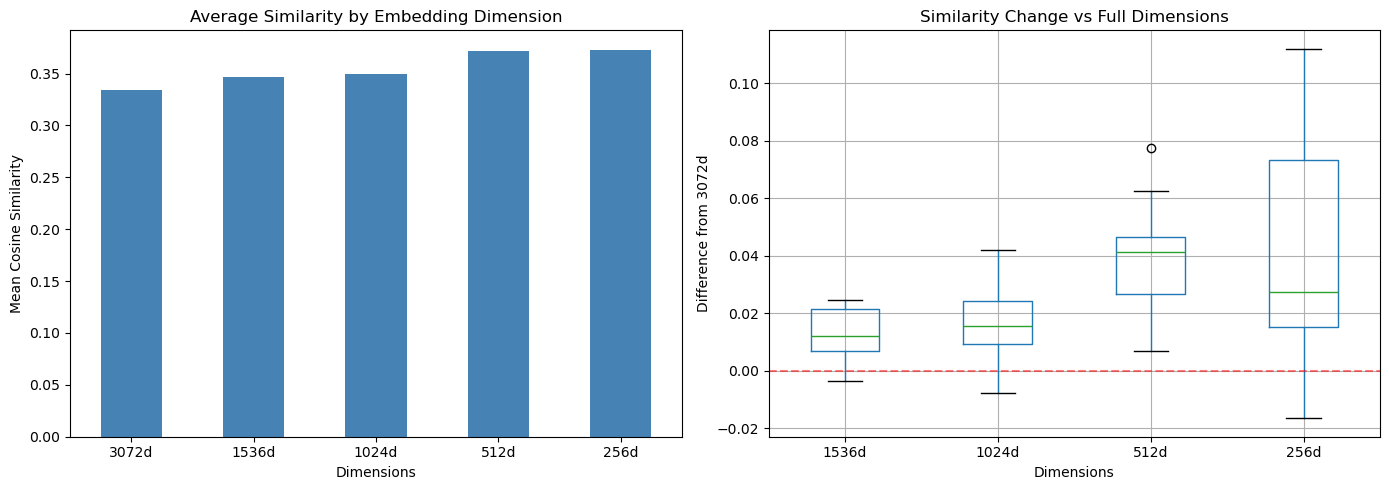


Dimension Reduction Analysis:
----------------------------------------
3072 -> 1536: correlation=0.9969, mean_diff=+0.0127
3072 -> 1024: correlation=0.9939, mean_diff=+0.0160
3072 -> 512: correlation=0.9863, mean_diff=+0.0381
3072 -> 256: correlation=0.9476, mean_diff=+0.0393


In [13]:
# Visualize dimension comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Similarity scores by dimension
df_dims.mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Dimensions")
axes[0].set_ylabel("Mean Cosine Similarity")
axes[0].set_title("Average Similarity by Embedding Dimension")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Plot 2: Degradation from full dimensions
degradation = df_dims.subtract(df_dims["3072d"], axis=0).drop(columns=["3072d"])
degradation.boxplot(ax=axes[1])
axes[1].axhline(y=0, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Dimensions")
axes[1].set_ylabel("Difference from 3072d")
axes[1].set_title("Similarity Change vs Full Dimensions")

plt.tight_layout()
plt.show()

# Summary stats
print("\nDimension Reduction Analysis:")
print("-" * 40)
for dims in [1536, 1024, 512, 256]:
    col = f"{dims}d"
    corr = df_dims['3072d'].corr(df_dims[col])
    diff = (df_dims[col] - df_dims['3072d']).mean()
    print(f"3072 -> {dims}: correlation={corr:.4f}, mean_diff={diff:+.4f}")

In [14]:
# Compare embedding models using Tiago's DOC_0
models = [
    ("text-embedding-3-small", None),   # 1536 dims default
    ("text-embedding-3-large", None),   # 3072 dims default
    ("text-embedding-3-large", 1536),   # Reduced to match small
    ("text-embedding-3-large", 1024),   # Further reduced
]

test_doc = docs["DOC_0_session_overview"]

print("Embedding DOC_0 with different models...")
model_embeddings = {}
model_query_embeddings = {}

for model, dims in models:
    key = f"{model}" + (f"_{dims}d" if dims else "")
    model_embeddings[key] = get_embedding(test_doc, model=model, dimensions=dims)
    model_query_embeddings[key] = get_embeddings_batch(test_queries, model=model, dimensions=dims)
    print(f"  {key}: {len(model_embeddings[key])} dimensions")

Embedding DOC_0 with different models...
  text-embedding-3-small: 1536 dimensions
  text-embedding-3-large: 3072 dimensions
  text-embedding-3-large_1536d: 1536 dimensions
  text-embedding-3-large_1024d: 1024 dimensions


In [15]:
# Calculate similarity scores by model
model_results = []

for q_idx, query in enumerate(test_queries):
    row = {"query": query}
    
    for key in model_embeddings.keys():
        q_emb = model_query_embeddings[key][q_idx]
        d_emb = model_embeddings[key]
        row[key] = similarity_score(q_emb, d_emb)
    
    model_results.append(row)

df_models = pd.DataFrame(model_results)
df_models = df_models.set_index("query")

print("\nSimilarity Scores by Model:\n")
print(df_models.round(4).to_string())


Similarity Scores by Model:

                                                 text-embedding-3-small  text-embedding-3-large  text-embedding-3-large_1536d  text-embedding-3-large_1024d
query                                                                                                                                                      
reverse shell activity                                           0.5218                  0.4691                        0.4860                        0.4838
hosts file modification                                          0.3940                  0.4075                        0.4099                        0.4122
high risk sessions                                               0.3891                  0.3752                        0.3798                        0.3856
reconnaissance before configuration change                       0.3801                  0.3086                        0.3200                        0.3240
network testing followed by system

## Experiment 4: Model Comparison

**Goal:** Is `text-embedding-3-large` worth the extra cost vs `text-embedding-3-small`?

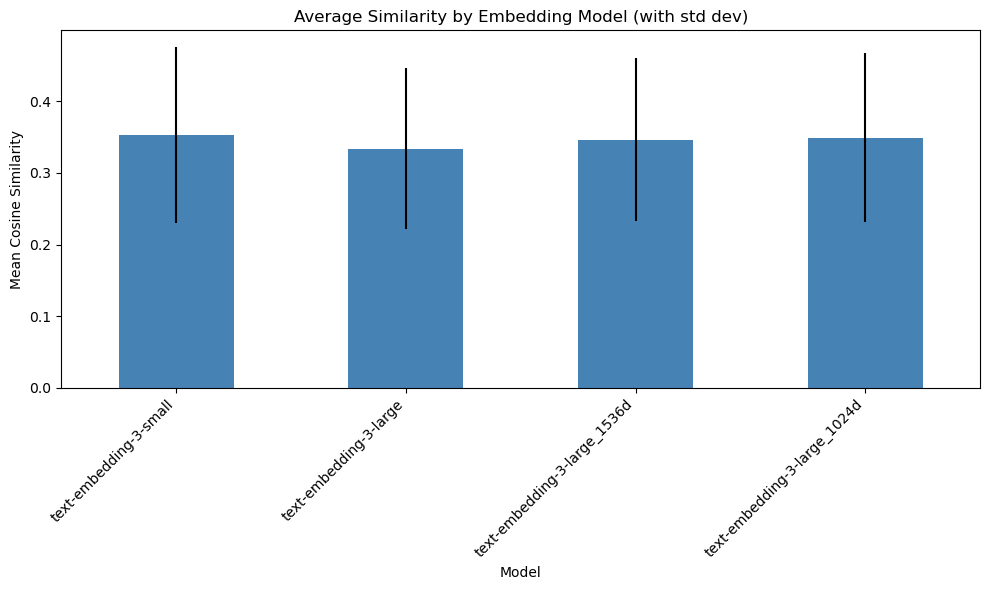

In [16]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))

df_models.mean().plot(kind="bar", ax=ax, color="steelblue", yerr=df_models.std())
ax.set_xlabel("Model")
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Average Similarity by Embedding Model (with std dev)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Summary and Recommendations

**Key questions answered:**
1. Are short docs (DOC 6-11) worth keeping, or is their content redundant with DOC 0?
2. Is 1024 dimensions sufficient, or does 3072 provide meaningful benefit?
3. Should we use `text-embedding-3-small` or `text-embedding-3-large`?

In [17]:
print("="*60)
print("DATA-DRIVEN SUMMARY")
print("="*60)

# 1. Short docs redundancy
print("\n1. ARE SHORT DOCS REDUNDANT?")
print("-" * 40)

short_docs = ['DOC_6_activity_network', 'DOC_7_activity_discovery', 'DOC_8_activity_hosts', 
              'DOC_9_activity_misc', 'DOC_10_suspicious_1', 'DOC_11_suspicious_2']
long_docs = ['DOC_0_session_overview', 'DOC_1_high_risk_command', 'DOC_2_network_commands',
             'DOC_3_file_operation', 'DOC_4_process_commands', 'DOC_5_benign_commands']

recall_with_all = []
recall_long_only = []

for query in test_queries:
    scores = df_docs.loc[query].sort_values(ascending=False)
    top_3_all = list(scores.index[:3])
    long_only_scores = scores[[d for d in scores.index if d in long_docs]]
    top_3_long_only = list(long_only_scores.index[:3])
    expected = expected_docs[query]
    
    expected_long_equiv = []
    for e in expected:
        if e in long_docs:
            expected_long_equiv.append(e)
        elif e == 'DOC_6_activity_network':
            expected_long_equiv.append('DOC_2_network_commands')
        elif e == 'DOC_7_activity_discovery':
            expected_long_equiv.append('DOC_3_file_operation')
        elif e == 'DOC_8_activity_hosts':
            expected_long_equiv.append('DOC_1_high_risk_command')
        elif e == 'DOC_9_activity_misc':
            expected_long_equiv.append('DOC_5_benign_commands')
        elif e in ['DOC_10_suspicious_1', 'DOC_11_suspicious_2']:
            expected_long_equiv.append('DOC_1_high_risk_command')
    expected_long_equiv = list(set(expected_long_equiv))
    
    r_all = len([d for d in expected if d in top_3_all]) / len(expected) if expected else 0
    r_long = len([d for d in expected_long_equiv if d in top_3_long_only]) / len(expected_long_equiv) if expected_long_equiv else 0
    
    recall_with_all.append(r_all)
    recall_long_only.append(r_long)

mean_all = sum(recall_with_all) / len(recall_with_all)
mean_long = sum(recall_long_only) / len(recall_long_only)
recall_diff = mean_all - mean_long

print(f"Mean Recall@3 with all 12 docs: {mean_all:.0%}")
print(f"Mean Recall@3 with 6 long docs: {mean_long:.0%}")
print(f"Difference: {recall_diff:+.0%}")

# 2. Format comparison
print("\n\n2. FORMAT COMPARISON (bullet vs narrative vs structured)")
print("-" * 40)

format_means = df_formats.mean().sort_values(ascending=False)
for fmt, score in format_means.items():
    print(f"  {fmt}: {score:.4f}")

format_spread = spreads.mean()
print(f"\nMean spread (best-worst format): {format_spread:.4f}")

# 3. Dimension reduction
print("\n\n3. DIMENSION REDUCTION")
print("-" * 40)

dim_results = {}
for dims in [1536, 1024, 512, 256]:
    col = f"{dims}d"
    corr = df_dims['3072d'].corr(df_dims[col])
    diff = (df_dims[col] - df_dims['3072d']).mean()
    dim_results[dims] = {'corr': corr, 'diff': diff}
    print(f"3072 -> {dims}: correlation={corr:.4f}, mean_diff={diff:+.4f}")

# 4. Model comparison
print("\n\n4. MODEL COMPARISON")
print("-" * 40)

model_means = df_models.mean().sort_values(ascending=False)
for model, score in model_means.items():
    print(f"  {model}: {score:.4f}")

best_model = model_means.index[0]
worst_model = model_means.index[-1]
model_diff = model_means.iloc[0] - model_means.iloc[-1]

# RECOMMENDATIONS
print("\n\n" + "="*60)
print("RECOMMENDATIONS (based on data above)")
print("="*60)

# Short docs
print("\n1. SHORT DOCS (6-11):")
if abs(recall_diff) < 0.05:
    print(f"   Recall difference is only {recall_diff:+.0%}")
    print("   -> Consider removing short docs to reduce storage/complexity")
elif recall_diff > 0.10:
    print(f"   Recall improvement is {recall_diff:+.0%}")
    print("   -> Keep short docs, they provide meaningful value")
else:
    print(f"   Recall difference is {recall_diff:+.0%}")
    print("   -> Marginal value, decide based on storage constraints")

# Format
print("\n2. TEXT FORMAT:")
if format_spread < 0.03:
    print(f"   Mean spread is only {format_spread:.4f}")
    print("   -> Format has minimal impact, choose based on readability")
elif format_spread < 0.06:
    best_format = format_means.index[0]
    print(f"   Mean spread is {format_spread:.4f}, best format: {best_format}")
    print(f"   -> Consider using {best_format} format")
else:
    best_format = format_means.index[0]
    print(f"   Mean spread is {format_spread:.4f}, best format: {best_format}")
    print(f"   -> Format matters significantly, use {best_format}")

# Dimensions
print("\n3. DIMENSIONS:")
corr_1024 = dim_results[1024]['corr']
if corr_1024 > 0.99:
    print(f"   3072->1024 correlation is {corr_1024:.4f}")
    print("   -> Safe to use 1024 dimensions (3x storage savings)")
elif corr_1024 > 0.95:
    print(f"   3072->1024 correlation is {corr_1024:.4f}")
    print("   -> 1024 dimensions acceptable, minor quality tradeoff")
else:
    print(f"   3072->1024 correlation is {corr_1024:.4f}")
    print("   -> Consider keeping full 3072 dimensions")

# Model
print("\n4. MODEL:")
if model_diff < 0.02:
    print(f"   Best vs worst model difference is only {model_diff:.4f}")
    print("   -> Use text-embedding-3-small (cheaper, similar quality)")
elif model_diff < 0.05:
    print(f"   Best model ({best_model}) is {model_diff:.4f} better")
    print("   -> Small improvement, weigh against 5x cost difference")
else:
    print(f"   Best model ({best_model}) is {model_diff:.4f} better")
    print("   -> Consider text-embedding-3-large for better quality")

DATA-DRIVEN SUMMARY

1. ARE SHORT DOCS REDUNDANT?
----------------------------------------
Mean Recall@3 with all 12 docs: 84%
Mean Recall@3 with 6 long docs: 87%
Difference: -2%


2. FORMAT COMPARISON (bullet vs narrative vs structured)
----------------------------------------
  prose: 0.3846
  bullets: 0.3776
  narrative: 0.3700
  structured: 0.3546
  original_numbered: 0.3525

Mean spread (best-worst format): 0.0841


3. DIMENSION REDUCTION
----------------------------------------
3072 -> 1536: correlation=0.9969, mean_diff=+0.0127
3072 -> 1024: correlation=0.9939, mean_diff=+0.0160
3072 -> 512: correlation=0.9863, mean_diff=+0.0381
3072 -> 256: correlation=0.9476, mean_diff=+0.0393


4. MODEL COMPARISON
----------------------------------------
  text-embedding-3-small: 0.3527
  text-embedding-3-large_1024d: 0.3494
  text-embedding-3-large_1536d: 0.3465
  text-embedding-3-large: 0.3338


RECOMMENDATIONS (based on data above)

1. SHORT DOCS (6-11):
   Recall difference is only -2%
  